In [1]:
# 1 Backtracking Algorithms 

def is_safe(board, row, col, n):
    # Check column
    for i in range(row):
        if board[i] == col:
            return False

    for i, j in zip(range(row, -1, -1), range(col, -1, -1)):
        if board[i] == j:
            return False

    for i, j in zip(range(row, -1, -1), range(col, n)):
        if board[i] == j:
            return False

    return True


def solve_n_queens(board, row, n):
    if row == n:
        print(board)
        return True

    for col in range(n):
        if is_safe(board, row, col, n):
            board[row] = col
            solve_n_queens(board, row + 1, n)
            board[row] = -1  # Backtrack


n = 4
board = [-1] * n
solve_n_queens(board, 0, n)

[1, 3, 0, 2]
[2, 0, 3, 1]


In [2]:
# Task 2 : Branch and Bound Algorithms

class Item:
    def __init__(self, value, weight):
        self.value = value
        self.weight = weight
        self.ratio = value / weight


def bound(items, n, W, profit, weight, level):
    if weight >= W:
        return 0

    profit_bound = profit
    j = level + 1
    total_weight = weight

    while j < n and total_weight + items[j].weight <= W:
        total_weight += items[j].weight
        profit_bound += items[j].value
        j += 1

    if j < n:
        profit_bound += (W - total_weight) * items[j].ratio

    return profit_bound


def knapsack(items, W):
    items.sort(key=lambda x: x.ratio, reverse=True)

    max_profit = 0

    def solve(level, profit, weight):
        nonlocal max_profit

        if weight <= W and profit > max_profit:
            max_profit = profit

        if level + 1 < len(items):
            b = bound(items, len(items), W, profit, weight, level)
            if b > max_profit:
                solve(level + 1, profit + items[level + 1].value,
                      weight + items[level + 1].weight)

                solve(level + 1, profit, weight)

    solve(-1, 0, 0)
    return max_profit


items = [Item(60, 10), Item(100, 20), Item(120, 30)]
W = 50
print("Max Profit:", knapsack(items, W))

Max Profit: 220


In [3]:
# Task 3 : String Matching Algorithms

def naive_search(text, pattern):
    n, m = len(text), len(pattern)
    comparisons = 0

    for i in range(n - m + 1):
        for j in range(m):
            comparisons += 1
            if text[i + j] != pattern[j]:
                break
        else:
            print("Pattern found at index", i)

    return comparisons


def compute_lps(pattern):
    lps = [0] * len(pattern)
    length = 0
    i = 1

    while i < len(pattern):
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1
        else:
            if length != 0:
                length = lps[length - 1]
            else:
                lps[i] = 0
                i += 1
    return lps


def kmp_search(text, pattern):
    lps = compute_lps(pattern)
    i = j = 0
    comparisons = 0

    while i < len(text):
        comparisons += 1
        if text[i] == pattern[j]:
            i += 1
            j += 1

        if j == len(pattern):
            print("Pattern found at index", i - j)
            j = lps[j - 1]

        elif i < len(text) and text[i] != pattern[j]:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return comparisons


text = "ABABDABACDABABCABAB"
pattern = "ABABCABAB"

print("Naive Comparisons:", naive_search(text, pattern))
print("KMP Comparisons:", kmp_search(text, pattern))

Pattern found at index 10
Naive Comparisons: 29
Pattern found at index 10
KMP Comparisons: 21


Pattern found at index 99
Pattern found at index 99
Pattern found at index 499
Pattern found at index 499
Pattern found at index 999
Pattern found at index 999
Pattern found at index 1999
Pattern found at index 1999


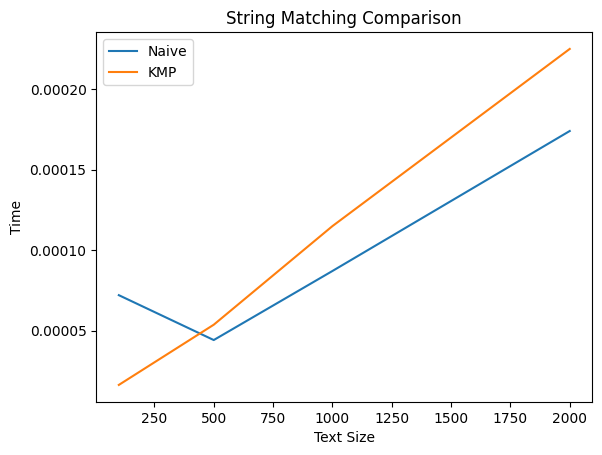

In [4]:
# Task 4 : Experimental Comparison of String Matching 

import time
import matplotlib.pyplot as plt

sizes = [100, 500, 1000, 2000]
naive_times = []
kmp_times = []

for size in sizes:
    text = "A" * size + "B"
    pattern = "AB"

    start = time.time()
    naive_search(text, pattern)
    naive_times.append(time.time() - start)

    start = time.time()
    kmp_search(text, pattern)
    kmp_times.append(time.time() - start)

plt.plot(sizes, naive_times, label="Naive")
plt.plot(sizes, kmp_times, label="KMP")
plt.xlabel("Text Size")
plt.ylabel("Time")
plt.legend()
plt.title("String Matching Comparison")
plt.show()

In [5]:
# Task 5 : Conceptual Programming Tasks

def naive_search(text, pattern):
    # Get lengths of text and pattern
    n = len(text)
    m = len(pattern)

    # Loop over each possible starting index in text
    for i in range(n - m + 1):

        # Try matching pattern at position i
        for j in range(m):

            # Compare characters one by one
            if text[i + j] != pattern[j]:
                # If mismatch occurs, stop checking further
                break

        # If loop completes without break → pattern matched
        else:
            print("Pattern found at index", i)